# Overview
This module is designed to for students to perform data modeling for kinetics data of drug degradation. Students will use Google Colab, Gemini, and Python programming language to read, interpret, and analyze provided experimental data.

Written by Dr. Linlin Jensen

Epalrestat experimental data taken from Sun et al., Journal of Pharmaceutical Analysis (2019), Vol. 9, 423 - 430, https://doi.org/10.1016/j.jpha.2018.08.002

> **AI Use Disclaimer:** This module is created with the assistance of Google Gemini.

### Learning Objectives
By the end of this recitation, you will be able to:
* Scientific Skills
  - **Data Interpretation:** Interpret and compare rate constants across temperatures and pHs in a table.
  - **Graphical Representation:** Visualize the differences between $k$ as a function of $T$ and $\text{ln} k$ as a function of $1/T$ for a reaction under different pHs using Python modeling.
  - **Mathematical Modeling:** Analyze how the slopes and y-intercept of the graph relate to reaction activation energies $E_a$ and frequency factor $A$.
  
* Cyberinfrastructure Skills
  - **Data Handling:** Import and load a CSV file into a Pandas DataFrame.
  - **Python Programming:**
    - Access and open a notebook in Google Colab
    - Identify and use the key components of the Google Colab interface (code cells, text cells, run button).
    - Read and understand a Python script with comments.
    - Run a Python script and interpret its output.
  - **Data Cleaning/Transformation:** Create new columns using mathematical models.
  - **Data Visualization:** Generate a scatter plot and a linear regression line using Python libraries (e.g., Pandas, Matplotlib, NumPy/SciPy).
  - **Computational Analysis:** Perform a linear fit to find the slope and intercept.
  - **AI Literacy:** Formulate effective and specific prompts to get the most out of an AI assistant.

# Getting Started

## Download Files and Open Google Colab

1. Download the Colab notebook file (*.ipynb*) and the corresponding *.csv* file for your assigned molecule from your recitation Canvas course. Once downloaded, these files will typically appear in your computer's Download folder.

2. Open your web browser and go to https://colab.research.google.com/.

3. Sign in with your Google account. If you don't have one, create a free account to continue.


## Open the Notebook in Colab:

4. On the Colab homepage, select File -> Open notebook.

5. Choose the **Upload** table and upload the downloaded *.ipynb* file.


## Upload the Experimental Data to Colab Worksheet.

6. In the left sidebar, click the folder icon to open the file browser.

7. Use the **Upload** button to add your *.csv* data file. Once uploaded, it will appear under the file list (below the subfolder sample_data).

## Gemini Prompt Tips:

For any step in the activities, if Gemini provides a list of tasks and asks you to choose between auto complete or step by step, select **Cancel**. Then copy and paste your prompt again, adding **Output only the full code block** at the end.


## Read and Verify the Experimental Data

Ask Gemini to read in the data from the uploaded file. To achieve this, following the steps below:

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Read the first three columns of the CSV file into a dataframe and display all rows.**"
4. Click the "Accept & Run" button to run the cell.

> After the cell finishes executing, review the printed concentration and time values. Confirm that the displayed data matches the contents of your .csv file


In [ ]:
import pandas as pd

# Read the CSV file, selecting only the first three columns
df = pd.read_csv('Epalrestat_k_T_pH.csv', usecols=[0, 1, 2])

# Display all rows of the DataFrame
print(df.to_string())

       pH  T (°C)  k(h-1)
0    1.85      25  0.0160
1    1.85      37  0.0206
2    1.85      60  0.0234
3    1.85      80  0.0282
4    1.85     100  0.0655
5    3.13      25  0.0159
6    3.13      37  0.0194
7    3.13      60  0.0206
8    3.13      80  0.0297
9    3.13     100  0.0627
10   5.00      25  0.0060
11   5.00      37  0.0115
12   5.00      60  0.0191
13   5.00      80  0.0302
14   5.00     100  0.0717
15   7.10      25  0.0043
16   7.10      37  0.0153
17   7.10      60  0.0195
18   7.10      80  0.0280
19   7.10     100  0.0695
20   9.08      25  0.0033
21   9.08      37  0.0122
22   9.08      60  0.0194
23   9.08      80  0.0264
24   9.08     100  0.0690
25  10.97      25  0.0016
26  10.97      37  0.0036
27  10.97      60  0.0140
28  10.97      80  0.0267
29  10.97     100  0.0724


# Step 1: Visualize Imported Data

**1. Plot rate constant as a function of T for each pH value**

- click on "+ Code" below, a code cell will appear
- Click on <u>generate</u> with AI
- Paste the following prompt: "**Plot rate constant vs. temperature for each pH on one graph, using distinct colors (e.g., gray, blue, green, red), and connect the points with lines.**"
- Click the "Accept & Run" button to run the cell.

**2. Plot rate constant as a function of pH for each T value**

- click on "+ Code" below, a code cell will appear
- Click on <u>generate</u> with AI
- Paste the following prompt: "**Plot rate constant vs. pH for each temperature on one graph, using distinct colors (e.g., gray, blue, green, red), and connect the points with lines.**"
- Click the "Accept & Run" button to run the cell.

> Right-click the images and paste them into your worksheet. Answer the guiding questions.

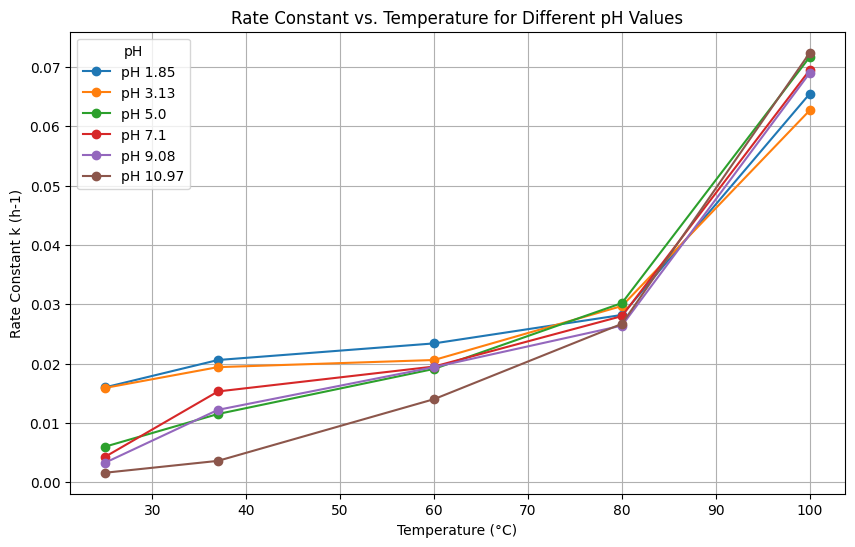

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'df' is available from previous steps
# If running this cell independently, uncomment and run the following line:
# df = pd.read_csv('Epalrestat_k_T_pH.csv', usecols=[0, 1, 2])

# Get unique pH values
unique_ph = df['pH'].unique()

# Define a list of colors for plotting, or use a colormap
# Using a qualitative colormap for better distinction if many pH values
colors = plt.colormaps.get_cmap('tab10')

plt.figure(figsize=(10, 6))

# Plot k vs T for each pH
for i, ph_value in enumerate(unique_ph):
    ph_data = df[df['pH'] == ph_value]
    plt.plot(ph_data['T (°C)'], ph_data['k(h-1)'], marker='o', linestyle='-', color=colors(i), label=f'pH {ph_value}')

plt.title('Rate Constant vs. Temperature for Different pH Values')
plt.xlabel('Temperature (°C)')
plt.ylabel('Rate Constant k (h-1)')
plt.legend(title='pH')
plt.grid(True)
plt.show()

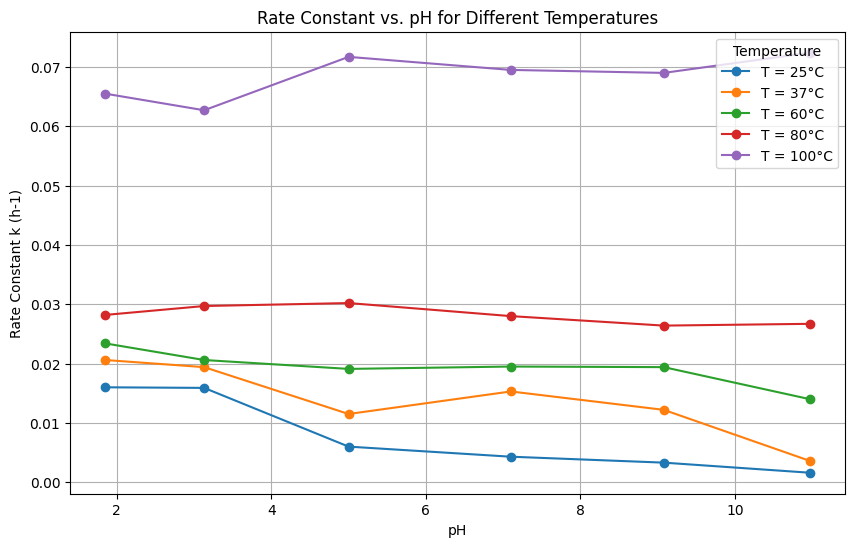

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'df' is available from previous steps
# If running this cell independently, uncomment and run the following line:
# df = pd.read_csv('Epalrestat_k_T_pH.csv', usecols=[0, 1, 2])

# Get unique temperature values
unique_temps = df['T (°C)'].unique()

# Define a colormap for distinct colors
colors = plt.colormaps.get_cmap('tab10')

plt.figure(figsize=(10, 6))

# Plot k vs pH for each temperature
for i, temp_value in enumerate(unique_temps):
    temp_data = df[df['T (°C)'] == temp_value]
    plt.plot(temp_data['pH'], temp_data['k(h-1)'], marker='o', linestyle='-', color=colors(i), label=f'T = {temp_value}°C')

plt.title('Rate Constant vs. pH for Different Temperatures')
plt.xlabel('pH')
plt.ylabel('Rate Constant k (h-1)')
plt.legend(title='Temperature')
plt.grid(True)
plt.show()

# Step 2: Transform Data and Visualize Transformed Data

## Transform $k$ to $\text{ln}k$, $T$ to unit of Kelvin, then $1/T$

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**For each pH, calculate lnk, convert T to Kelvin, and compute 1/T.**"
4. Click the "Accept & Run" button to run the cell.


In [ ]:
import numpy as np

# Calculate ln(k)
df['lnk'] = np.log(df['k(h-1)'])

# Convert T (°C) to Kelvin
df['T_K'] = df['T (°C)'] + 273.15

# Compute 1/T (in K^-1)
df['1/T'] = 1 / df['T_K']

# Display the updated DataFrame with the new columns
print(df.to_string())

       pH  T (°C)  k(h-1)       lnk     T_K       1/T
0    1.85      25  0.0160 -4.135167  298.15  0.003354
1    1.85      37  0.0206 -3.882464  310.15  0.003224
2    1.85      60  0.0234 -3.755019  333.15  0.003002
3    1.85      80  0.0282 -3.568433  353.15  0.002832
4    1.85     100  0.0655 -2.725705  373.15  0.002680
5    3.13      25  0.0159 -4.141436  298.15  0.003354
6    3.13      37  0.0194 -3.942482  310.15  0.003224
7    3.13      60  0.0206 -3.882464  333.15  0.003002
8    3.13      80  0.0297 -3.516608  353.15  0.002832
9    3.13     100  0.0627 -2.769394  373.15  0.002680
10   5.00      25  0.0060 -5.115996  298.15  0.003354
11   5.00      37  0.0115 -4.465408  310.15  0.003224
12   5.00      60  0.0191 -3.958067  333.15  0.003002
13   5.00      80  0.0302 -3.499913  353.15  0.002832
14   5.00     100  0.0717 -2.635265  373.15  0.002680
15   7.10      25  0.0043 -5.449140  298.15  0.003354
16   7.10      37  0.0153 -4.179902  310.15  0.003224
17   7.10      60  0.0195 -3

## Visualize transformed data:

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Plot lnk vs. 1/T for each pH on one plot. Connect points with lines and use different colors (e.g., gray, blue, green, red) for clarity.**"
4. Click the "Accept & Run" button to run the cell.

> Right-click the image and paste it into your worksheet. Answer the guiding questions.

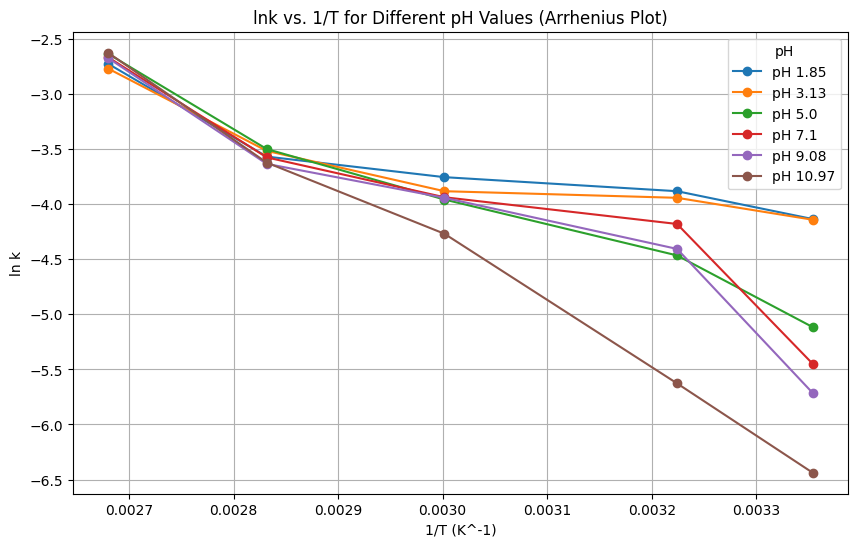

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'df' is available from previous steps and contains 'lnk' and '1/T' columns
# If running this cell independently, ensure 'df' is loaded and transformed

# Get unique pH values
unique_ph = df['pH'].unique()

# Define a colormap for distinct colors
colors = plt.colormaps.get_cmap('tab10')

plt.figure(figsize=(10, 6))

# Plot lnk vs. 1/T for each pH
for i, ph_value in enumerate(unique_ph):
    ph_data = df[df['pH'] == ph_value]
    plt.plot(ph_data['1/T'], ph_data['lnk'], marker='o', linestyle='-', color=colors(i), label=f'pH {ph_value}')

plt.title('lnk vs. 1/T for Different pH Values (Arrhenius Plot)')
plt.xlabel('1/T (K^-1)')
plt.ylabel('ln k')
plt.legend(title='pH')
plt.grid(True)
plt.show()

## Regression Analysis

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**For each pH, run a linear regression, overlay only the fitted line (make it thicker), display slope/intercept/R², and plot experimental points as scatter with distinct markers.**"
4. Click the "Accept & Run" button to run the cell.

> Right-click the image and paste it into your worksheet. Answer the guiding questions.

Linear Regression Results for each pH:
--------------------------------------
pH 1.85:
  Slope: -1762.1383
  Intercept: 1.7053
  R-squared: 0.8195


pH 3.13:
  Slope: -1785.8718
  Intercept: 1.7398
  R-squared: 0.8277


pH 5.0:
  Slope: -3367.8982
  Intercept: 6.2304
  R-squared: 0.9723


pH 7.1:
  Slope: -3462.1574
  Intercept: 6.4881
  R-squared: 0.8937


pH 9.08:
  Slope: -3862.4293
  Intercept: 7.5838
  R-squared: 0.9146


pH 10.97:
  Slope: -5527.2517
  Intercept: 12.1665
  R-squared: 0.9948




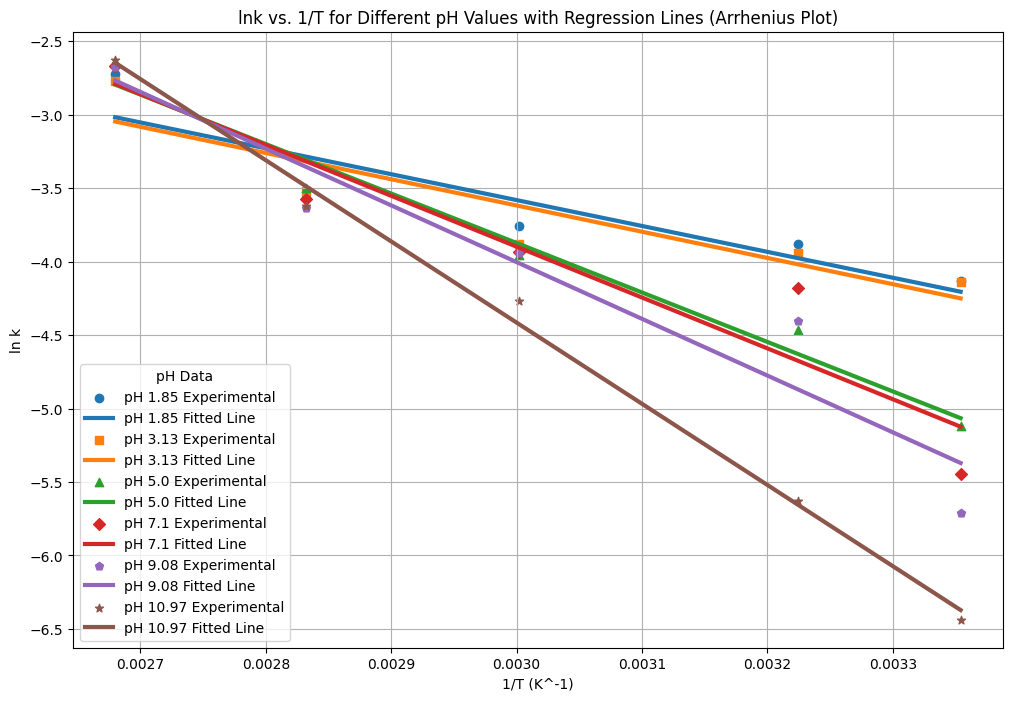

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
import numpy as np

# Ensure 'df' is available from previous steps and contains 'lnk' and '1/T' columns

unique_ph = df['pH'].unique()

plt.figure(figsize=(12, 8))

# Define a colormap for distinct colors and markers for plotting
colors = plt.colormaps.get_cmap('tab10')
markers = ['o', 's', '^', 'D', 'p', '*'] # Different markers for clarity

print("Linear Regression Results for each pH:")
print("--------------------------------------")

for i, ph_value in enumerate(unique_ph):
    ph_data = df[df['pH'] == ph_value]
    x = ph_data['1/T']
    y = ph_data['lnk']

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r_squared = r_value**2

    # Plot experimental points as scatter with distinct markers
    plt.scatter(x, y, color=colors(i), marker=markers[i % len(markers)], label=f'pH {ph_value} Experimental')

    # Plot the fitted line, making it thicker
    plt.plot(x, slope * x + intercept, color=colors(i), linestyle='-', linewidth=3, label=f'pH {ph_value} Fitted Line')

    # Display slope, intercept, and R²
    print(f"pH {ph_value}:")
    print(f"  Slope: {slope:.4f}")
    print(f"  Intercept: {intercept:.4f}")
    print(f"  R-squared: {r_squared:.4f}")
    print("\n")

plt.title('lnk vs. 1/T for Different pH Values with Regression Lines (Arrhenius Plot)')
plt.xlabel('1/T (K^-1)')
plt.ylabel('ln k')
plt.legend(title='pH Data')
plt.grid(True)
plt.show()

# Step 3: Parameter Estimation

1. click on "+ Code" below, a code cell will appear
2. Click on <u>generate</u> with AI
3. Paste the following prompt: "**Use the linear regression results to calculate the activation energy (kJ/mol) and the frequency factor A for pH=5.**"
4. Click the "Accept & Run" button to run the cell.

> Record the values and answer the guiding questions in your recitation worksheet.

In [9]:
import numpy as np

# Define the gas constant R in kJ/(mol·K)
R_GAS_CONSTANT = 0.008314  # kJ/(mol·K)

# For pH = 5.0, from the previous regression results:
slope_ph5 = -3367.8982
intercept_ph5 = 6.2304

# Calculate Activation Energy (Ea) in kJ/mol
# slope = -Ea / R
# Ea = -slope * R
ea_kj_mol = -slope_ph5 * R_GAS_CONSTANT

# Calculate Frequency Factor (A)
# intercept = ln(A)
# A = exp(intercept)
frequency_factor_A = np.exp(intercept_ph5)

print(f"For pH = 5.0:")
print(f"Activation Energy (Ea): {ea_kj_mol:.2f} kJ/mol")
print(f"Frequency Factor (A): {frequency_factor_A:.2e}")

For pH = 5.0:
Activation Energy (Ea): 28.00 kJ/mol
Frequency Factor (A): 5.08e+02


# Step 4: Reflection:

**Complete the reflection questions in the recitation worksheet.**

# Final Notes about Grading:
In addition to completing the guiding questions, your TA will check that you followed the activity instructions. Submit shareable links to your Colab Notebook as part of your participation. **To share your Colab notebook:**

1. Rename your copy: Change the filename to include YOUR name (the student's name), not your instructor's name.

2. Share your notebook: Set the sharing permissions so that anyone with the link can view (or as your instructor specifies).

3.	Copy and paste your sharable links into the Exit Form so your instructor and TA can access your work.